<a href="https://colab.research.google.com/github/Ewanjohndennis/ML_LAB/blob/main/assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Q1 Compare **Maximum Likelihood Estimation (MLE)** and **Maximum A Posteriori (MAP)** for estimating the probability of passing a quiz.

### Given
- Quiz results (1 = Pass, 0 = Fail):
```text
1, 1, 0, 1, 1, 0, 1, 0, 1, 1
```
- Assume the data follows a **Bernoulli distribution**.
- Let **θ** be the probability of passing.
- Prior distribution: **Beta(α = 5, β = 2)**.

## Tasks
### Part A – MLE
- Count the number of passes and total observations.
- Compute the **Maximum Likelihood Estimate (MLE)** of θ.

### Part B – MAP
- Using the Beta prior (α = 5, β = 2), compute the **Maximum A Posteriori (MAP)** estimate of θ.

### Part C – Comparison
- Compare the MLE and MAP estimates.
- Explain the difference between them.

### Part D – Visualization
Plot the following on the same graph:
- Prior Distribution
- Likelihood Function
- Posterior Distribution

### Part E – Discussion
Answer the following:
1. Which estimate uses prior knowledge?
2. Why are the MLE and MAP estimates different?
3. Which estimate is more reliable for a very small dataset?

Theta MLE :  0.7
Theta MAP : 0.7333333333333333


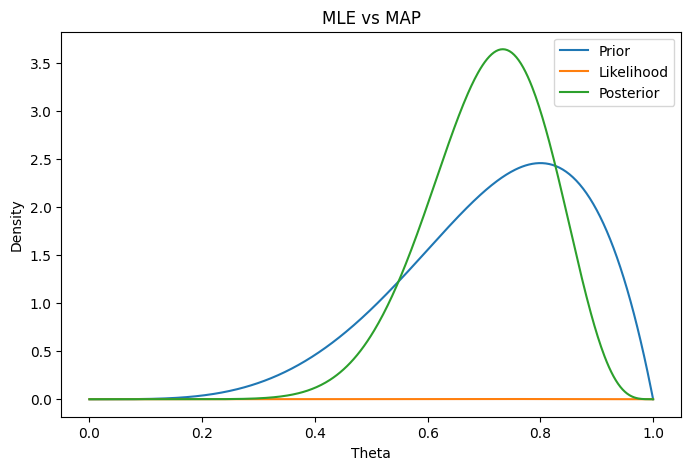

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta


X = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([1,1,0,1,1,0,1,0,1,1])

positive_cases = y.sum()
total_cases = len(y)

theta_mle = (positive_cases/total_cases)

print("Theta MLE : ",theta_mle)

alpha ,beta_param = 5 , 2

theta_map = (positive_cases + alpha -1)/(total_cases + alpha + beta_param - 2)

print("Theta MAP :",theta_map)

theta = np.linspace(0,1,500)

prior = beta.pdf(theta,5,2)

likelihood = theta**positive_cases * (1-theta)**(total_cases - positive_cases)

posterior = beta.pdf(theta,12,5)

plt.figure(figsize=(8,5))
plt.plot(theta,prior,label="Prior")
plt.plot(theta,likelihood,label="Likelihood")
plt.plot(theta,posterior,label="Posterior")
plt.xlabel("Theta")
plt.ylabel("Density")
plt.title("MLE vs MAP")
plt.legend()
plt.show()

## Q2: Problem
A machine fills bottles with fruit juice. The fill volumes are assumed to follow a Gaussian distribution with known variance.

### Given
- Observations: `52, 49, 51, 53, 48, 50, 54, 51, 49, 52`
- Known variance: `σ² = 4 ml²`
- Prior mean: `μ₀ = 50 ml`
- Prior variance: `σ₀² = 9 ml²`

## Tasks

### Part A
Compute the sample mean.

### Part B
Estimate the population mean using MLE.

### Part C
Estimate the population mean using MAP with the Gaussian prior.

### Part D
Compare the Sample Mean, MLE, and MAP estimates.

### Part E
Plot the Gaussian Prior, Likelihood, and Posterior on the same graph.

### Part F
Discuss:
1. Which estimate is influenced by prior knowledge?
2. Why is MAP closer to the prior mean?
3. What happens when more observations are collected?

Sample Mean :  50.9
MLE : 50.9
MAP : 50.86170212765957


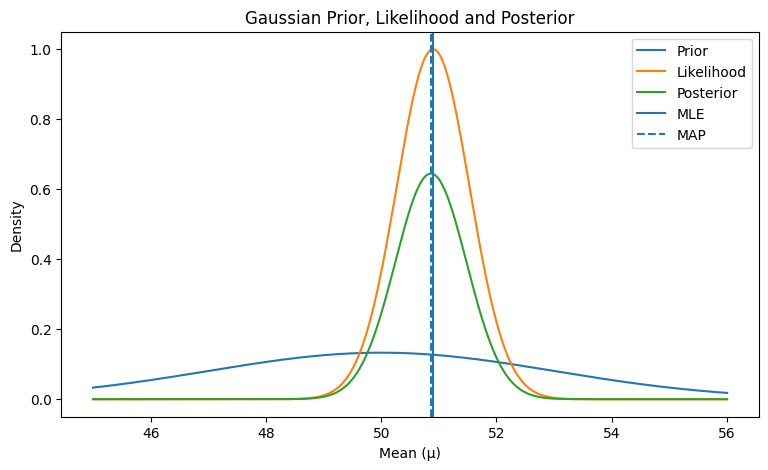

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

X = np.array([52, 49, 51, 53, 48, 50, 54, 51, 49, 52])

n = len(X)
sample_mean = X.mean()

print("Sample Mean : ",sample_mean)

mu_mle = sample_mean
print("MLE :",mu_mle)

prior_mean = 50 #mu0
prior_var = 9 #sigma0^2
known_var = 4 #sigma^2

mu_map = ( (n*sample_mean/known_var) + (prior_mean/prior_var) )/( (n/known_var) + (1/prior_var) )
print("MAP :",mu_map)

mu_values = np.linspace(45, 56, 500)

prior = norm.pdf(
    mu_values,
    loc=prior_mean,
    scale=np.sqrt(prior_var)
)

likelihood = np.exp(
    -n * (mu_values - sample_mean)**2
    / (2 * known_var)
)

posterior_variance = 1 / (
    n / known_var +
    1 / prior_var
)

posterior_std = np.sqrt(
    posterior_variance
)

posterior = norm.pdf(
    mu_values,
    loc=mu_map,
    scale=posterior_std
)


plt.figure(figsize=(9,5))

plt.plot(mu_values,prior,label="Prior")

plt.plot(mu_values,likelihood,label="Likelihood")

plt.plot(mu_values,posterior,label="Posterior")

plt.axvline(mu_mle,linestyle="-",label="MLE")

plt.axvline(mu_map,linestyle="--",label="MAP")

plt.xlabel("Mean (μ)")
plt.ylabel("Density")

plt.title("Gaussian Prior, Likelihood and Posterior")

plt.legend()
plt.show()

# Q3: Logistic Regression using MLE and MAP

## Objective
Predict whether a student passes an entrance examination using Study Hours and Attendance Percentage.

- `1` → Pass
- `0` → Fail

## Tasks

### Part A – Load and Explore
- Load `student_exam.csv` using Pandas.
- Display the first five rows, shape, data types, and summary statistics.

### Part B – Preprocessing
- Separate features and target.
- Split into 80% training and 20% testing data.
- Standardize the features.

### Part C – Logistic Regression using MLE
- Train Logistic Regression without regularization (`C=1e6`).
- Calculate Accuracy, Precision, Recall, F1-score, and Confusion Matrix.
- Display the model coefficients.

### Part D – Logistic Regression using MAP
- Train Logistic Regression using L2 regularization (`C=1.0`).
- Calculate Accuracy, Precision, Recall, F1-score, and Confusion Matrix.
- Display the model coefficients.

### Part E – Comparison
- Compare MLE and MAP coefficients.
- Identify which model is less likely to overfit.
- Explain the effect of the Gaussian prior.

### Part F – Prediction
For a student with:
- Study Hours = `6`
- Attendance = `76%`

Predict Pass/Fail using both MLE and MAP models and compare their probabilities.

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,recall_score,f1_score


df = pd.read_csv('student_exam.csv')

print(df.head())
print("Shape : ",df.shape)

X = df[['Study Hours','Attendance']]
y = df['Pass']

print("Shape After : ",X.shape)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MLE
lr_mle = LogisticRegression(C=1e6,max_iter=10000)
lr_mle.fit(X_train_scaled,y_train)

y_predict = lr_mle.predict(X_test_scaled)

mle_accuracy = accuracy_score(y_test,y_predict)
mle_precision = precision_score(y_test,y_predict)
mle_recall = recall_score(y_test,y_predict)
mle_f1 = f1_score(y_test,y_predict)
mle_confusion = confusion_matrix(y_test,y_predict)

print("\nMLE MODEL================================\n")

print("Accuracy :", mle_accuracy)
print("Precision:", mle_precision)
print("Recall   :", mle_recall)
print("F1 Score :", mle_f1)
print("Confusion Matrix :\n",mle_confusion)


print("MLE Coefficients :")
print(lr_mle.coef_)

print("\nStudy Hours coefficient:",lr_mle.coef_[0][0])
print("Attendance coefficient:",lr_mle.coef_[0][1])


# MAP
lr_map = LogisticRegression(penalty='l2',C=1,max_iter=10000)
lr_map.fit(X_train_scaled,y_train)

y_predict = lr_map.predict(X_test_scaled)

map_accuracy = accuracy_score(y_test,y_predict)
map_precision = precision_score(y_test,y_predict)
map_recall = recall_score(y_test,y_predict)
map_f1 = f1_score(y_test,y_predict)
map_confusion = confusion_matrix(y_test,y_predict)

print("\nMAP MODEL==============================\n")

print("Accuracy :", map_accuracy)
print("Precision:", map_precision)
print("Recall   :", map_recall)
print("F1 Score :", map_f1)
print("Confusion Matrix :\n",map_confusion)


print("MAP Coefficients :")
print(lr_map.coef_)

print("\nStudy Hours coefficient:",lr_map.coef_[0][0])
print("Attendance coefficient:",lr_map.coef_[0][1])



coefficient_comparison = pd.DataFrame({
    "Feature": [
        "Study Hours",
        "Attendance"
    ], "MLE": lr_mle.coef_[0],"MAP": lr_map.coef_[0]})

print(coefficient_comparison)

new_student = pd.DataFrame({"Study Hours": [6],"Attendance": [76]})

new_student_scaled = scaler.transform(new_student)

mle_prediction = lr_mle.predict(new_student_scaled)
map_prediction = lr_map.predict(new_student_scaled)


mle_probability = lr_mle.predict_proba(new_student_scaled)

map_probability = lr_map.predict_proba(new_student_scaled)

print("\nMLE Prediction:", mle_prediction[0])
print("MLE Probability:")
print(mle_probability)

print("\nMAP Prediction:", map_prediction[0])
print("MAP Probability:")
print(map_probability)

   Student  Study Hours  Attendance  Pass
0        1            2          55     0
1        2            3          60     0
2        3            4          58     0
3        4            4          65     0
4        5            5          70     1
Shape :  (20, 4)
Shape After :  (20, 2)

MLE MODEL================================

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Confusion Matrix :
 [[1 0]
 [0 3]]
MLE Coefficients :
[[24.10666053  3.40239659]]

Study Hours coefficient: 24.106660530466893
Attendance coefficient: 3.402396586962388

MAP MODEL==============================

Accuracy : 0.75
Precision: 0.75
Recall   : 1.0
F1 Score : 0.8571428571428571
Confusion Matrix :
 [[0 1]
 [0 3]]
MAP Coefficients :
[[1.37857139 1.04398574]]

Study Hours coefficient: 1.3785713876531045
Attendance coefficient: 1.0439857410669502
       Feature        MLE       MAP
0  Study Hours  24.106661  1.378571
1   Attendance   3.402397  1.043986

MLE Prediction: 1
MLE Probability:
[[4.

#### Estimate the parameters of a logistic regression model using MLE and MAP on the Breast Cancer Wisconsin dataset. Compare the results and discuss the effects of regularization.
Tasks:

● Load and preprocess the dataset.

● Implement logistic regression with MLE.

● Apply MAP estimation with different regularization priors (L1 and L2 regularization).

● Compare the performance and parameter estimates with MLE and MAP.

In [4]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)
print(data.feature_names)

(569, 30)
(569,)
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [6]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

def sigmoid(z):
  return (1)/(1+(np.exp(-z)))


In [7]:
def train_mle(X,y,learning_rate=0.01,epochs=5000):
  n_samples,n_features = X.shape

  weights = np.zeros(n_features)
  bias = 0

  for epoch in range(epochs):
    #Linear Combination
    z = np.dot(X,weights) + bias

    #Predicting Probabilities
    predictions = sigmoid(z)

    #Gradients
    dw = np.dot(X.T,(y-predictions)) / n_samples
    db = np.sum(y-predictions) / n_samples

    #Gradient Ascent
    weights += learning_rate*dw
    bias += learning_rate*db

  return weights, bias

In [8]:
#MAP with L2 Regularization
def train_map_l2(X,y,learning_rate=0.01,epochs=5000,l2_lambda=0.01):
  n_samples,n_features = X.shape

  weights = np.zeros(n_features)
  bias = 0

  for epoch in range(epochs):
    z = np.dot(X,weights) + bias
    predictions = sigmoid(z)

    #L2 Regularization
    dw = (np.dot(X.T,(y-predictions)) / n_samples) - l2_lambda*weights
    db = np.sum(y - predictions) / n_samples

    weights += learning_rate*dw
    bias += learning_rate*db

  return weights,bias

In [9]:
#MAP with l1 Regularization
def train_map_l1(X,y,learning_rate=0.01,epochs=5000,l1_lambda=0.01):
  n_samples,n_features = X.shape

  weights = np.zeros(n_features)
  bias = 0

  for epoch in range(epochs):
    z = np.dot(X,weights) + bias

    predictions = sigmoid(z)

    #L1 Regularized Gradient
    dw = (np.dot(X.T,(y-predictions)) / n_samples) - l1_lambda*np.sign(weights)
    db = np.sum(y-predictions) / n_samples

    weights += learning_rate * dw
    bias += learning_rate * db

  return weights , bias

In [10]:
from sklearn.metrics import accuracy_score


def predict(X, weights, bias):

    probabilities = sigmoid(
        np.dot(X, weights) + bias
    )

    predictions = (probabilities >= 0.5).astype(int)

    return predictions


weights_mle, bias_mle = train_mle(
    X_train,
    y_train
)

weights_l1, bias_l1 = train_map_l1(
    X_train,
    y_train,
    l1_lambda=0.01
)

weights_l2, bias_l2 = train_map_l2(
    X_train,
    y_train,
    l2_lambda=0.01
)

y_pred_mle = predict(X_test, weights_mle, bias_mle)
y_pred_l1 = predict(X_test, weights_l1, bias_l1)
y_pred_l2 = predict(X_test, weights_l2, bias_l2)

print("MLE Accuracy :", accuracy_score(y_test, y_pred_mle))
print("L1 Accuracy  :", accuracy_score(y_test, y_pred_l1))
print("L2 Accuracy  :", accuracy_score(y_test, y_pred_l2))



MLE Accuracy : 0.9736842105263158
L1 Accuracy  : 0.9736842105263158
L2 Accuracy  : 0.9824561403508771


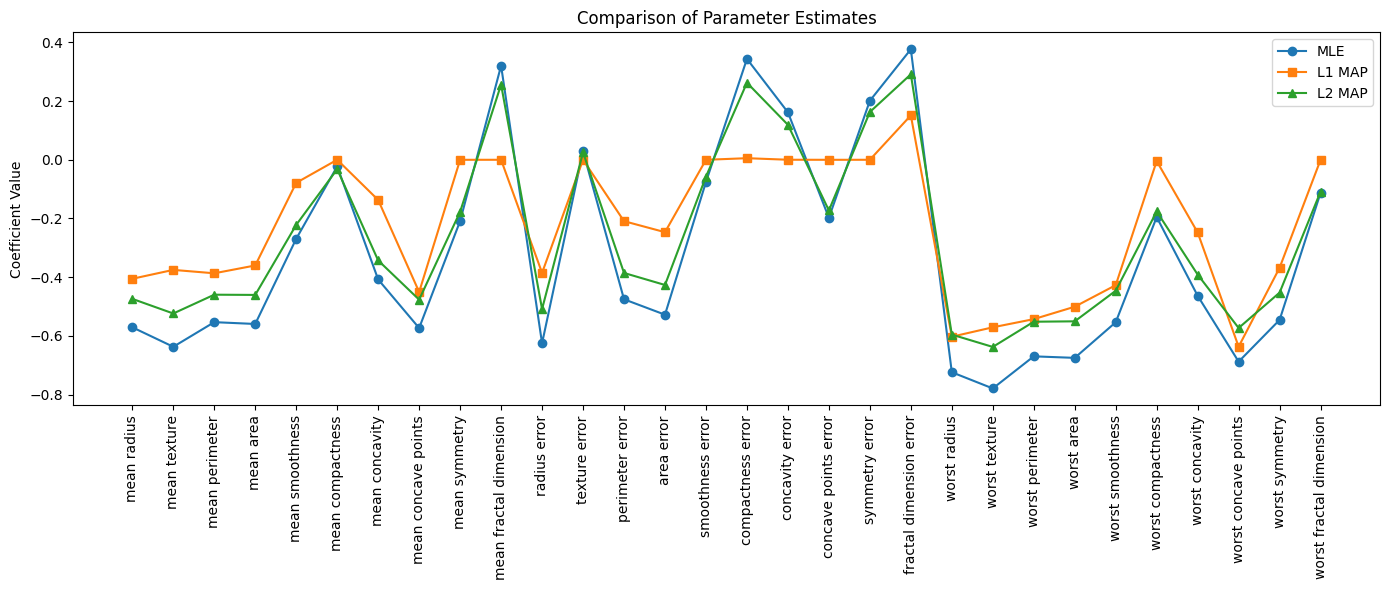

In [11]:
import matplotlib.pyplot as plt

x = np.arange(len(data.feature_names))

plt.figure(figsize=(14, 6))

plt.plot(x, weights_mle, marker='o', label='MLE')
plt.plot(x, weights_l1, marker='s', label='L1 MAP')
plt.plot(x, weights_l2, marker='^', label='L2 MAP')

plt.xticks(
    x,
    data.feature_names,
    rotation=90
)

plt.ylabel("Coefficient Value")
plt.title("Comparison of Parameter Estimates")
plt.legend()
plt.tight_layout()
plt.show()

#### Use MLE and MAP to estimate the parameters of a multinomial distribution on the 20 Newsgroups dataset. Explore the impact of different priors on the estimation.
Tasks:

● Load and preprocess the dataset.

● Implement MLE for multinomial distribution parameter estimation.

● Apply MAP estimation with various priors (e.g., Dirichlet priors).

● Compare results and evaluate the effect of different priors.

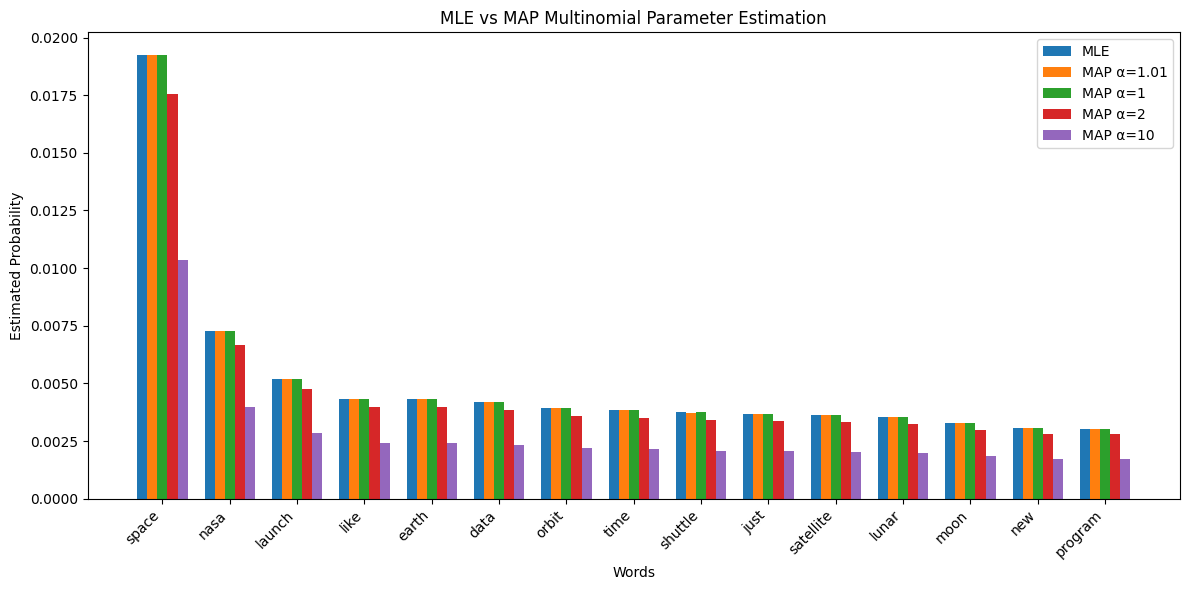

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

categories = [
    "alt.atheism", "comp.graphics", "comp.sys.ibm.pc.hardware",
    "rec.autos", "sci.med", "sci.space",
    "talk.politics.misc", "rec.sport.baseball"
]

data = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=5000,
    min_df=2
)

X = vectorizer.fit_transform(data.data)

class_index = data.target_names.index("sci.space")
X_class = X[data.target == class_index]

counts = np.asarray(X_class.sum(axis=0)).flatten()
vocabulary = np.array(vectorizer.get_feature_names_out())

theta_mle = counts / counts.sum()

def map_estimate(counts, alpha):
    theta = counts + alpha - 1
    return theta / theta.sum()

alphas = [1.01, 1, 2, 10]
map_results = {alpha: map_estimate(counts, alpha) for alpha in alphas}

top = np.argsort(theta_mle)[-15:][::-1]
words = vocabulary[top]

x = np.arange(len(words))
width = 0.15

plt.figure(figsize=(12, 6))
plt.bar(x - 2 * width, theta_mle[top], width, label="MLE")

for i, alpha in enumerate(alphas):
    plt.bar(
        x + (i - 1) * width,
        map_results[alpha][top],
        width,
        label=f"MAP α={alpha}"
    )

plt.xticks(x, words, rotation=45, ha="right")
plt.xlabel("Words")
plt.ylabel("Estimated Probability")
plt.title("MLE vs MAP Multinomial Parameter Estimation")
plt.legend()
plt.tight_layout()
plt.show()